# Tesla Deliveries & Production Data Analysis

## End-to-End Machine Learning Pipeline


**Question :** 
Designed and implemented an end-to-end ML pipeline on sales/price data covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

**Resource/data:**
https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025

# Importing All the Needed Library

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import KFold,cross_val_score,GridSearchCV
from statsmodels.tsa.stattools import adfuller
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import os
from sklearn.preprocessing import StandardScaler



# Loading the Dataset into a Dataframe and Displaying its Shape , no. of Column , Information and a General Description


In [13]:
df = pd.read_csv("C:/Users/Deepak/Desktop/celeb_technology/week2/data/tesla_deliveries_dataset_2015_2025.csv")
print("The shape of the dataset",df.shape)
print("\nThe columns are : " , df.columns)

The shape of the dataset (2640, 12)

The columns are :  Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='str')


In [10]:
print("\nDataset information : ")
df.info()


Dataset information : 
<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


In [11]:
print("\nDescriptive Statistics of the dataset are : " , "\n",df.describe())


Descriptive Statistics of the dataset are :  
               Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
max    2025.000000    12.000000          25704.000000      28939.000000   

       Avg_Price_USD  Battery_Capacity_kWh     Range_km  CO2_Saved_tons  \
count    2640.000000           2640.000000  2640.000000     2640.000000   
mean    84907.340330             87.059470   500.257576      744.076989   
std     20123.258036             20.836265   120.86

**We do this function to get a general description of the dataset , using columns we get the name of all the feature which help us to indentify the target and predictor variable. 
The shape function help us to observe how many row and column are present which help us to understand the size of dataset.
The info(). function show us the data type of each column and show all non-null values.
The describle() function give us statistic summery of the numerical columns.**


# Checking for Missing Values and Duplicate Records

In [15]:
print(f"The number of duplicate Records are {df.duplicated().sum()}")

The number of duplicate Records are 0


In [16]:
print("The no. of missing value per colummn are :")
df.isna().sum()

The no. of missing value per colummn are :


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

**We check the dataset for any duplicate row and if we find any we remove them 
We also check for missing value which can be dealt using various technique.**

# Exploratory Data Analysis


In [18]:
print("Numerical data type columns :",list(df.select_dtypes(include=['int','float']).columns))
print("\nCategorical data type coulums:",list(df.select_dtypes(include=['object']).columns))

Numerical data type columns : ['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

Categorical data type coulums: ['Region', 'Model', 'Source_Type']


C:\Users\Deepak\AppData\Local\Temp\ipykernel_24996\3790768887.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("\nCategorical data type coulums:",list(df.select_dtypes(include=['object']).columns))


In [20]:

os.makedirs("../outputs/plots", exist_ok=True)

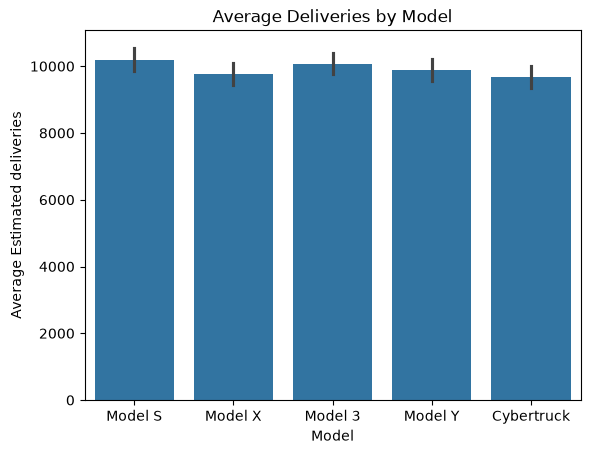

In [21]:
plt.Figure(figsize=(8,5))
sns.barplot(x='Model',y='Estimated_Deliveries',data=df,estimator=np.mean)
plt.title('Average Deliveries by Model')
plt.xlabel('Model')
plt.ylabel('Average Estimated deliveries')
plt.savefig("../outputs/plots/deliveries_by_model.png")
plt.show()

The average deliveries of all model are fairly similiar which mean no model outperforms the other in terms of average deliveries

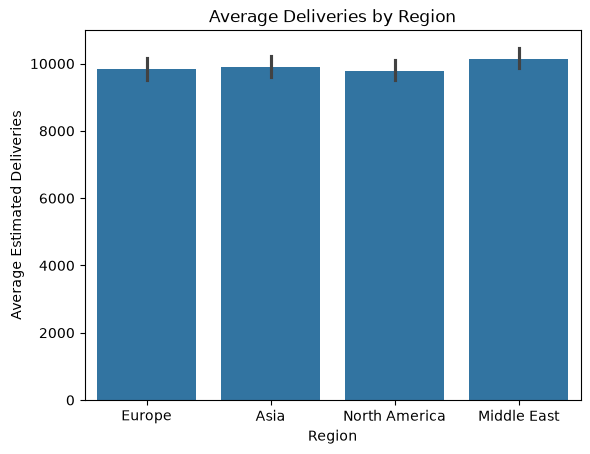

In [22]:
plt.Figure(figsize=(8,5))
sns.barplot(x='Region',y='Estimated_Deliveries',data=df,estimator=np.mean)
plt.title("Average Deliveries by Region")
plt.xlabel('Region')
plt.ylabel('Average Estimated Deliveries')
plt.savefig("../outputs/plots/deliveries_by_region.png")
plt.show()

The average deliveries by the region are fairly similiar to each other , meaning no region have noticable higher or lower delivery in the region

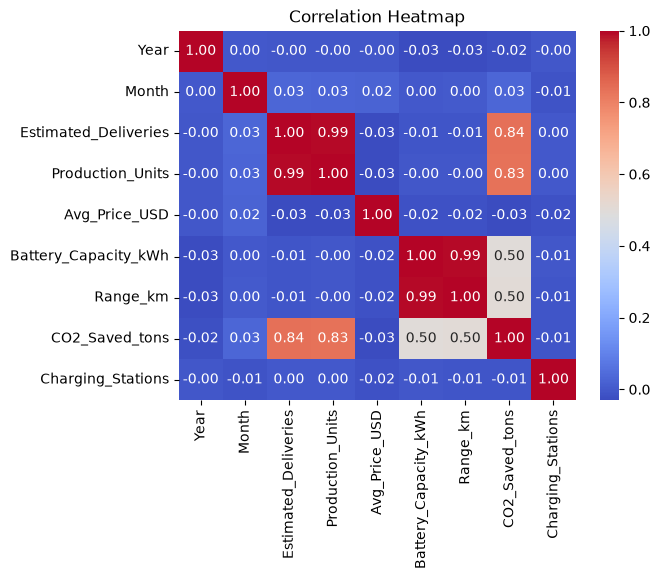

In [23]:
plt.Figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig("../outputs/plots/corr_graph.png")
plt.show()


The correlation heatmap reveals several strong positive relationships among the numerical variables. Estimated deliveries and production units exhibit an almost perfect positive correlation (r = 0.99), indicating that higher production levels are closely associated with increased vehicle deliveries. Similarly, battery capacity and driving range are highly correlated (r = 0.99), suggesting that larger battery capacities contribute to longer vehicle ranges.
Additionally, CO₂ savings show a strong positive correlation with both estimated deliveries (r = 0.84) and production units (r = 0.83), highlighting the environmental benefits associated with greater electric vehicle adoption. Most of the remaining variables exhibit weak or negligible correlations, indicating limited linear relationships with the target variable.

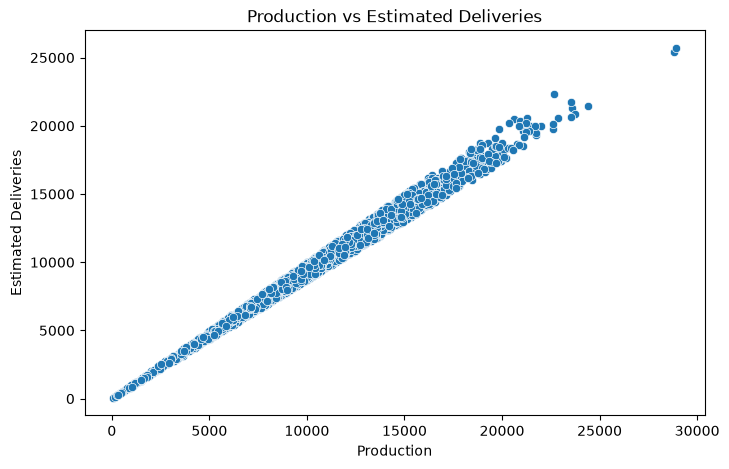

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Production_Units',
    y='Estimated_Deliveries',
    data=df
)

plt.title('Production vs Estimated Deliveries')
plt.xlabel('Production')
plt.ylabel('Estimated Deliveries')
plt.savefig("../outputs/plots/scatter_production_delivery.png")
plt.show()


The scatter plot reveals a strong positive linear relationship between production units and estimated deliveries. As vehicle production increases, estimated deliveries also increase proportionally, indicating that production is a major driver of deliveries.


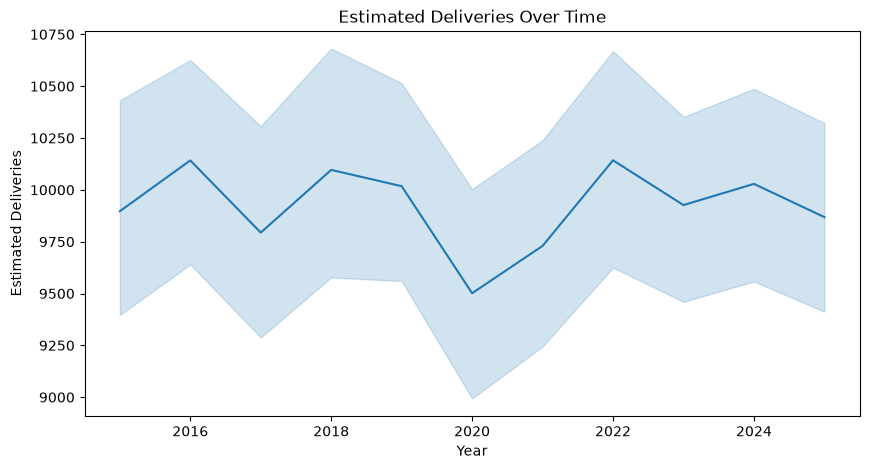

In [26]:
plt.figure(figsize=(10,5))
sns.lineplot(
    x='Year',
    y='Estimated_Deliveries',
    data=df
)

plt.title('Estimated Deliveries Over Time')
plt.xlabel('Year')
plt.ylabel('Estimated Deliveries')
plt.show()


The line plot illustrates the variation in estimated deliveries. The results indicate that deliveries remain relatively stable over the observed period, with only minor year-to-year fluctuations. A noticeable decline is observed around 2020, followed by a recovery in subsequent years. Overall, the dataset does not exhibit a strong increasing or decreasing trend, suggesting that the year variable has a limited influence on estimated deliveries.


**Five exploratory data analysis (EDA) charts were created to gain insights into the dataset. Bar charts were used to compare deliveries across different Tesla models and regions. A correlation heatmap was generated to identify relationships among numerical variables and detect potential multicollinearity. A scatter plot was used to examine the relationship between production units and estimated deliveries, while a time-series line plot was created to analyze delivery trends over time. These visualizations provide valuable insights into data distributions, feature relationships, and patterns that can influence predictive modeling.**


# Feature Engineering

In [28]:
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region'] = le_region.fit_transform(df['Region'])
df['Model'] = le_model.fit_transform(df['Model'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])


we used label encoding to encode the categorical columns values to a numerical values so we can apply different model on it.

In [42]:
df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)
df["Deliveries_Lag1"] = df["Deliveries_Lag1"].fillna(
    df["Deliveries_Lag1"].mean()
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Deliveries_Lag1,Rolling_Mean_3
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,9924.959454,9923.677407
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,17646.000000,9923.677407
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,3797.000000,9951.333333
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,8411.000000,6254.333333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,6555.000000,9113.333333


In [44]:

df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
    .rolling(window=3)
    .mean()
)

df["Rolling_Mean_3"] = df["Rolling_Mean_3"].fillna(
    df["Rolling_Mean_3"].mean()
)


two time-series features are engineered: Deliveries_Lag1, representing the previous period's deliveries, and Rolling_Mean_3, representing the three-period moving average of deliveries. Missing values generated during feature creation were imputed using the respective feature means.

**Feature engineering transforms the raw dataset into a format suitable for machine learning. This includes creating new features, encoding categorical variables, and preparing the feature matrix and target variable.
Above we use it because machine learning models cannot understand time dependencies automatically.**

# Chronological data split

In [45]:
X = df.drop("Estimated_Deliveries", axis=1)
y = df["Estimated_Deliveries"]
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2640, 13)
Target Shape: (2640,)


In [46]:
split_index = int(len(X) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (2112, 13)
Testing Set: (528, 13)


In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed done")

Feature scaling completed done


**In time series problems, we use chronological splitting because future observations should never be used to predict past observations. Random splitting can introduce data leakage and lead to overly optimistic performance estimates. A chronological split mimics real-world forecasting, where models are trained on historical data and used to predict future values**

# Linear Regression

In [48]:
linearR_model = LinearRegression()
linearR_model.fit(X_train_scaled,y_train);
y_pred = linearR_model.predict(X_test_scaled)

LR_MAE = mean_absolute_error(y_pred,y_test)
LR_RMSE=np.sqrt(mean_squared_error(y_pred,y_test))
LR_R2=r2_score(y_pred,y_test)

print("the Performance Metrics")
print(f"the MAE :{LR_MAE:.2f}")
print(f"The R2 score : {LR_R2:.4f}")
print(f"RMSE score : {LR_RMSE:.2f}")

the Performance Metrics
the MAE :310.33
The R2 score : 0.9907
RMSE score : 375.56


Linear Regression is a supervised machine learning algorithm used for predicting continuous values. The model is trained using the scaled training data, and its performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.
### Model Performance Evaluation
The Linear Regression model achieved an MAE of 310.33 and an RMSE of 375.56, indicating that the model's predictions differ from the actual deliveries by approximately 310–376 units on average. The R² score of 0.9907 suggests that the model explains approximately 99.07% of the variability in estimated deliveries, demonstrating an excellent fit to the data.
The relatively small difference between MAE and RMSE indicates that the model does not suffer from significant prediction outliers and produces consistent predictions.

# Decision Tree

In [49]:
decisionTree = DecisionTreeRegressor(
    random_state=46
)
decisionTree.fit(X_train,y_train);
dr_y_pred = decisionTree.predict(X_test);
dt_mae = mean_absolute_error(y_test, dr_y_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dr_y_pred))
dt_r2 = r2_score(y_test, dr_y_pred)
print("Decision Tree Performance")
print(f"MAE : {dt_mae:.2f}")
print(f"RMSE: {dt_rmse:.2f}")
print(f"R²  : {dt_r2:.4f}")

Decision Tree Performance
MAE : 383.34
RMSE: 519.28
R²  : 0.9824



Decision Tree Regression is a supervised machine learning algorithm that predicts continuous values by recursively splitting the dataset into smaller subsets. It can capture non-linear relationships and does not require feature scaling, although the scaled data is used here for consistency across models.

### Decision Tree Performance Evaluation

The Decision Tree Regressor achieved an MAE of 383.34 and an RMSE of 519.28, indicating that the model's predictions differ from the actual deliveries by approximately 383–519 units on average. The R² score of 0.9824 shows that the model explains approximately 98.24% of the variability in estimated deliveries, demonstrating strong predictive capability.

However, compared with the Linear Regression model, the Decision Tree exhibits higher prediction errors and a slightly lower R² score. This suggests that the underlying relationship between the features and the target variable is predominantly linear, making Linear Regression a more suitable model for this dataset.

# RandomForest Regression

In [50]:
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print(f"MAE : {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²  : {rf_r2:.4f}")

Random Forest Performance
MAE : 301.39
RMSE: 385.37
R²  : 0.9903



Random Forest Regression is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. The final prediction is obtained by averaging the outputs of all individual trees.

### Random Forest Performance Evaluation

The Random Forest Regressor achieved an MAE of 301.39, an RMSE of 385.37, and an R² score of 0.9903. These results indicate that the model predicts estimated deliveries with a high degree of accuracy and explains approximately 99.03% of the variability in the target variable.

Compared to the other models, Random Forest produced the lowest average prediction error (MAE). However, Linear Regression achieved a slightly lower RMSE and a marginally higher R² score. Overall, both models demonstrate excellent predictive performance, with Linear Regression being preferred due to its simplicity and slightly better overall fit.

# XGBoost

In [55]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_mae, xgb_rmse, xgb_r2=mean_absolute_error(y_test, xgb_pred),np.sqrt(mean_squared_error(y_test, xgb_pred)),r2_score(y_test, xgb_pred)
print("XGBoost Performance")
print(f"MAE : {mean_absolute_error(y_test, xgb_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, xgb_pred)):.2f}")
print(f"R²  : {r2_score(y_test, xgb_pred):.4f}")

XGBoost Performance
MAE : 255.23
RMSE: 334.59
R²  : 0.9927


XGBoost (Extreme Gradient Boosting) is an ensemble machine learning algorithm that builds many decision trees sequentially, where each new tree tries to correct the errors of the previous ones.

### XGBoost Performance Evaluation

The XGBoost Regressor achieved an MAE of 255.23, an RMSE of 334.59, and an R² score of 0.9927. These results indicate that the model predicts estimated deliveries with a very high degree of accuracy and explains approximately 99.27% of the variability in the target variable.


# CatBoost

In [54]:
cat = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=0
)

cat.fit(X_train, y_train)

cat_pred = cat.predict(X_test)
cat_mae=mean_absolute_error(y_test, cat_pred)
cat_rmse = np.sqrt(mean_squared_error(y_test,cat_pred))
car_r2 = r2_score(y_test,cat_pred)
print("CatBoost Performance")
print(f"MAE : {mean_absolute_error(y_test, cat_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, cat_pred)):.2f}")
print(f"R²  : {r2_score(y_test, cat_pred):.4f}")

CatBoost Performance
MAE : 308.56
RMSE: 386.14
R²  : 0.9903


CatBoost (Categorical Boosting) is a gradient boosting algorithm developed by Yandex that builds an ensemble of decision trees and is particularly effective at handling categorical features.

### CatBoost Performance Evaluation

The CatBoost Regressor achieved an MAE of 308.56, an RMSE of 386.14, and an R² score of 0.9903. These results indicate that the model predicts estimated deliveries with high accuracy and explains approximately 99.03% of the variability in the target variable.


# Model Comparsion

In [56]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "CatBoost"
    ],
    "MAE": [
        LR_MAE,
        dt_mae,
        rf_mae,
        xgb_mae,
        cat_mae
    ],
    "RMSE": [
        LR_RMSE,
        dt_rmse,
        rf_rmse,
        xgb_rmse,
        cat_rmse
    ],
    "R² Score": [
        LR_R2,
        dt_r2,
        rf_r2,
        xgb_r2,
        car_r2
    ]
})

comparison.head()

,Model,MAE,RMSE,R² Score
0,Linear Regression,310.334522,375.564666,0.990744
1,Decision Tree,383.340909,519.278338,0.982423
2,Random Forest,301.386818,385.372085,0.990319
3,XGBoost,255.233902,334.586814,0.992703
4,CatBoost,308.564660,386.137267,0.990281


# Conclusion:
XGBoost performed the as the best regressor model followed by Linear Regression Model .
As linear regression is a simple,interpretable and computationally efficient while XGBoost offer lower MAE,RMSE and higher R2 score.
That's why we choose XGBoost.

# 5-Fold Cross Validation

In [58]:

lr = LinearRegression()
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv=kf,
    scoring='r2'
)
print("Per-fold R² Scores:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean R² Score: {cv_scores.mean():.4f}")

Per-fold R² Scores:
Fold 1: 0.9902
Fold 2: 0.9909
Fold 3: 0.9907
Fold 4: 0.9899
Fold 5: 0.9901

Mean R² Score: 0.9904


Cross-validation checks whether the model performs consistently on different subsets of the data and is not just performing well on one particular train-test split.

### 5-Fold Cross Validation Results

The Linear Regression model achieved consistently high R² scores across all five folds, ranging from 0.9899 to 0.9909, with a mean R² score of 0.9904. The low variation among the fold scores indicates that the model generalizes well and produces stable predictions across different subsets of the data. Overall, the cross-validation results demonstrate that the model is robust and does not exhibit significant overfitting.

# GridSearchCV


In [64]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}
rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'n_estimators': 50}

Best CV Score:
0.9882516742839895


In [61]:
best_rf = grid_search.best_estimator_

best_rf.fit(X_train, y_train)

rf_pred = best_rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print(f"MAE : {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²  : {rf_r2:.4f}")

Random Forest Performance
MAE : 303.86
RMSE: 388.55
R²  : 0.9902


In [62]:
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
)

top10 = feature_importance.sort_values(
    ascending=False
).head(10)

top10

Production_Units     0.990055
CO2_Saved_tons       0.002163
Range_km             0.001221
Avg_Price_USD        0.001040
Charging_Stations    0.001004
Rolling_Mean_3       0.000955
Deliveries_Lag1      0.000923
Year                 0.000888
Month                0.000668
Model                0.000357
dtype: float64

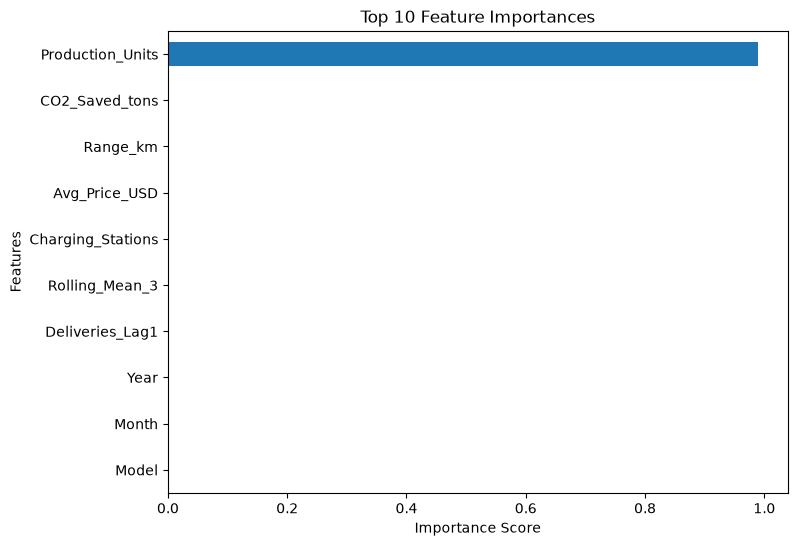

In [63]:
plt.figure(figsize=(8,6))

top10.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.savefig("../outputs/plots/gridsearch.png")
plt.show()

GridSearchCV systematically tests multiple hyperparameter combinations and selects the one that achieves the best cross-validation performance, helping improve the model's predictive capability.

### Random Forest Hyperparameter Tuning and Feature Importance

The optimal Random Forest model was obtained using 50 estimators and no restriction on tree depth. The tuned model achieved an MAE of 303.86, an RMSE of 388.55, and an R² score of 0.9902, indicating excellent predictive performance and explaining approximately 99.02% of the variability in estimated deliveries.

Feature importance analysis revealed that Production_Units is by far the most influential predictor, contributing nearly all of the model's predictive power. The remaining variables exhibited negligible importance, suggesting that estimated deliveries are primarily driven by production levels in this dataset.


# ADF Stationarity Test

- **Null Hypothesis (H₀):** The time series is non-stationary.
- **Alternative Hypothesis (H₁):** The time series is stationary.


In [65]:
result = adfuller(df['Estimated_Deliveries'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -53.82661259715622
p-value: 0.0
Critical Values:
1%: -3.432830360798943
5%: -2.8626358355986774
10%: -2.5673533514279425



If the p-value is less than 0.05, the null hypothesis is rejected, indicating that the series is stationary.

In [66]:
if result[1] < 0.05:
    print("Conclusion: The time series is stationary (Reject H₀).")
else:
    print("Conclusion: The time series is non-stationary (Fail to Reject H₀).")

Conclusion: The time series is stationary (Reject H₀).



The Augmented Dickey-Fuller (ADF) test is used to determine whether a time series is stationary. A stationary series has constant statistical properties over time, which is an important assumption for many forecasting techniques.

### Conclusion

The ADF test produced a p-value of 0.0, which is less than the significance level of 0.05. Therefore, the null hypothesis of non-stationarity is rejected. This indicates that the Estimated_Deliveries time series is stationary and suitable for time-series analysis.

# Time Series Forecasting


In [67]:
forecast_table = pd.DataFrame({
    'Actual': y_test.iloc[:20].values,
    'Predicted': xgb_pred[:20]
})

forecast_table['Error'] = (
    forecast_table['Actual']
    - forecast_table['Predicted']
)

forecast_table['Error %'] = (
    np.abs(forecast_table['Error'])
    / forecast_table['Actual']
) * 100

forecast_table = forecast_table.round(2)

forecast_table

,Actual,Predicted,Error,Error %
0,11974,11500.030273,473.97,3.96
1,9189,8929.490234,259.51,2.82
2,15956,16511.980469,-555.97,3.48
3,10336,10842.049805,-506.05,4.90
4,15152,15606.309570,-454.31,3.00
5,4224,3959.239990,264.76,6.27
6,8475,8766.110352,-291.11,3.43
7,4093,4037.229980,55.77,1.36
8,2972,2990.830078,-18.83,0.63
9,8208,8240.019531,-32.02,0.39


Time series forecasting is the process of predicting future values using historical observations collected over time. It identifies patterns such as trends, seasonality, and temporal dependencies to make future predictions.

### Forecast Table Interpretation

The forecast table compares the actual and predicted values for the first twenty observations in the test set. The majority of the predictions exhibit low error percentages, with most values falling below 5%. The minimum error percentage is approximately 0.08%, indicating an almost perfect prediction, while the maximum error percentage is approximately 6.27%.

Overall, the results suggest that the model provides accurate and reliable forecasts, with relatively small deviations between the predicted and actual delivery values.